In [29]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [46]:
ticker = 'NVDA'
df = yf.download(ticker, '2020-01-01')

/tmp/ipykernel_1533/3604355685.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [47]:
df

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.971078,5.971078,5.891683,5.942208,237536000
2020-01-03,5.875504,5.919308,5.826473,5.851362,205384000
2020-01-06,5.900145,5.905371,5.756039,5.782172,262636000
2020-01-07,5.971575,6.017370,5.883468,5.928517,314856000
2020-01-08,5.982775,6.024090,5.927273,5.967344,277108000
...,...,...,...,...,...
2026-02-24,192.850006,193.770004,187.399994,191.490005,175123600
2026-02-25,195.559998,197.630005,193.789993,194.449997,250637100


<Axes: xlabel='Date'>

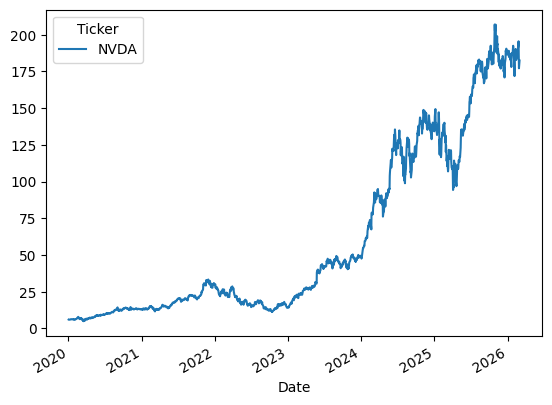

In [48]:
df.Close.plot()

In [49]:
scaler = StandardScaler()

In [50]:
df['Close'] = scaler.fit_transform(df['Close'])

In [51]:
df.Close

Ticker,NVDA
Date,
2020-01-02,-0.922990
2020-01-03,-0.924596
2020-01-06,-0.924182
2020-01-07,-0.922982
2020-01-08,-0.922794
...,...
2026-02-24,2.217394
2026-02-25,2.262934
2026-02-26,2.083631


In [52]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
  data.append(df.Close[i:i + seq_length])

data = np.array(data)


In [53]:
data

array([[[-0.92299037],
        [-0.92459644],
        [-0.92418237],
        ...,
        [-0.91128798],
        [-0.90934318],
        [-0.91007928]],

       [[-0.92459644],
        [-0.92418237],
        [-0.92298203],
        ...,
        [-0.90934318],
        [-0.91007928],
        [-0.90212853]],

       [[-0.92418237],
        [-0.92298203],
        [-0.92279382],
        ...,
        [-0.91007928],
        [-0.90212853],
        [-0.89929283]],

       ...,

       [[ 2.09909103],
        [ 2.05422337],
        [ 2.11992855],
        ...,
        [ 2.19554826],
        [ 2.217394  ],
        [ 2.26293372]],

       [[ 2.05422337],
        [ 2.11992855],
        [ 2.10614884],
        ...,
        [ 2.217394  ],
        [ 2.26293372],
        [ 2.08363103]],

       [[ 2.11992855],
        [ 2.10614884],
        [ 1.9690253 ],
        ...,
        [ 2.26293372],
        [ 2.08363103],
        [ 1.95423736]]])

In [54]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)

X_test= torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [55]:
class PredictionModel(nn.Module):

  def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
    super(PredictionModel, self).__init__()

    self.num_layers = num_layers
    self.hidden_dim = hidden_dim

    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True )
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device= device)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device= device)

    out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
    out = self.fc(out[:, -1, :])
    return out


In [56]:
model = PredictionModel(input_dim = 1, hidden_dim = 32, num_layers = 2, output_dim=1).to(device)

In [57]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [58]:
num_epochs = 200

for i in range(num_epochs):
  y_train_pred = model(X_train)

  loss = criterion(y_train_pred, y_train)

  if i % 25 == 0:
    print(i, loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

0 0.45626333355903625
25 0.010075710713863373
50 0.0021982286125421524
75 0.0015470831422135234
100 0.00139349396340549
125 0.0013117595808580518
150 0.001245449180714786
175 0.0011868873843923211


In [59]:
model.eval()
y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [62]:
train_rmse = root_mean_squared_error(y_train[:,0], y_train_pred[:,0])
test_rmse = root_mean_squared_error(y_test[:,0], y_test_pred[:,0])

In [63]:
train_rmse

2.0048727989196777

In [64]:
test_rmse

8.940001487731934

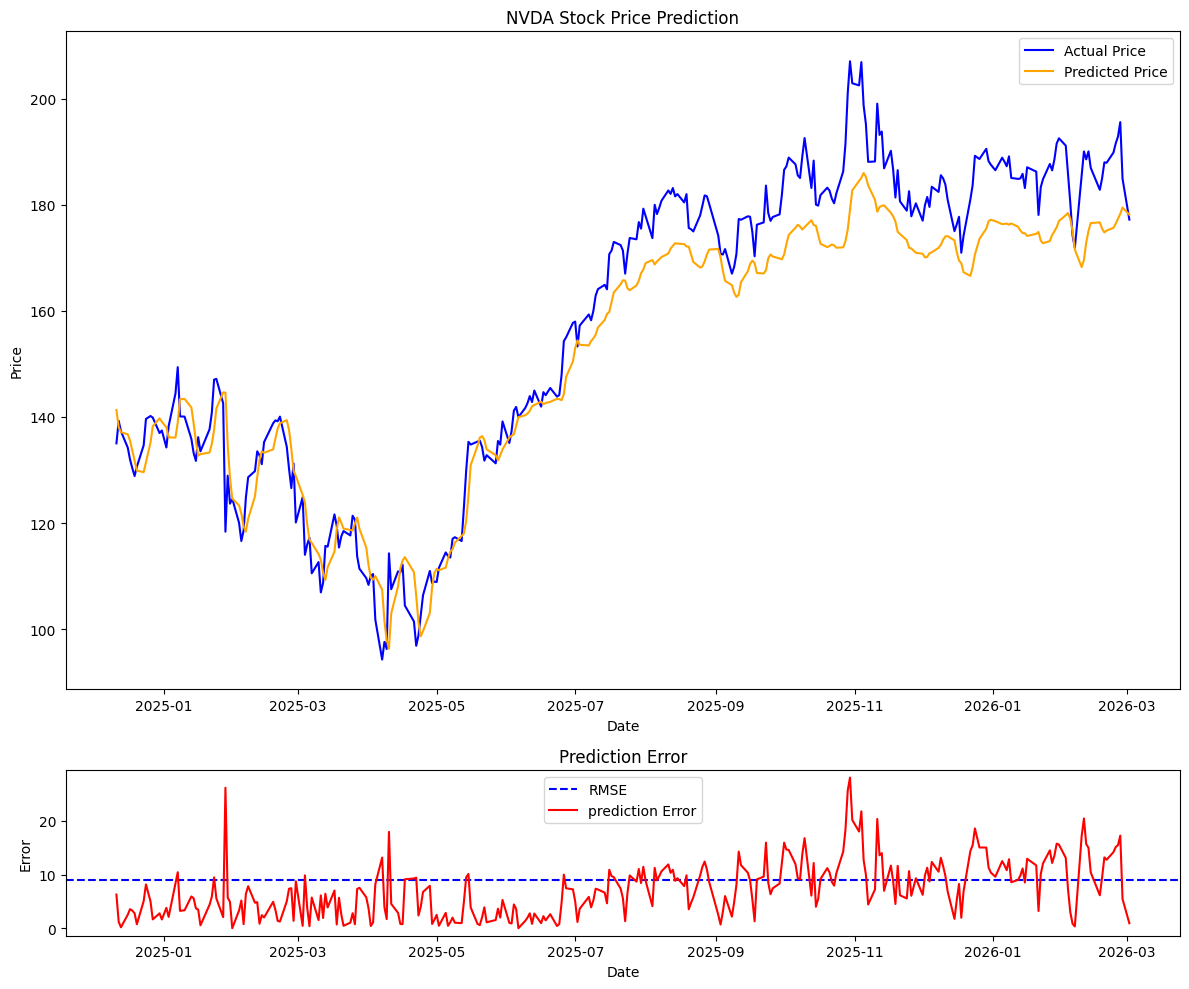

In [65]:
fig = plt.figure(figsize = (12, 10))

gs = fig.add_gridspec(4,1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = "Actual Price")
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'orange', label = "Predicted Price")
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel("Price")

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = "blue", linestyle= '--', label= "RMSE")
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = "prediction Error")
ax2.legend()
plt.title("Prediction Error")
plt.xlabel("Date")
plt.ylabel("Error")

plt.tight_layout()
plt.show()